In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import os
import matplotlib.pyplot as plt

# seaborn can be used to "prettify" default matplotlib plots by importing and setting as default
import seaborn as sns
sns.set_theme() # Set searborn as default

In [32]:
def load_data(file_path: str = "data/case1Data.csv") -> tuple[np.ndarray, np.ndarray]:
    # Load in the CSV data using numpy. The first column is the Y values.
    # No processing is done here.
    YX_ = np.genfromtxt(file_path, delimiter=",", skip_header=1)
    Y_, X_ = YX_[:, 0], YX_[:, 1:]  
    return Y_, X_

Y, X_raw = load_data()
X = X_raw.copy()

In [91]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer

def preprocess_features(
    X: np.ndarray,
    drop_idx: int,
    categorical_indices_after_drop: list[int]
) -> tuple[np.ndarray, dict]:
    n_samples, n_features = X.shape
    drop_idx

    if not (0 <= drop_idx < n_features):
        raise ValueError(
            f"Requested feature {drop_idx} to drop, but X has only {n_features} features."
        )

    keep_mask = np.ones(n_features, dtype=bool)
    keep_mask[drop_idx] = False
    X_reduced = X[:, keep_mask]

    remaining_original_indices = np.arange(n_features)[keep_mask]

    cat_idx = np.array(categorical_indices_after_drop)
    cont_idx = np.setdiff1d(np.arange(n_features-1), cat_idx)

    if len(cont_idx) > 0:
        cont_imputer = SimpleImputer(
            strategy="mean",
            missing_values=np.nan,
        )
        X_cont = cont_imputer.fit_transform(X_reduced[:, cont_idx])
    else:
        cont_imputer = None
        X_cont = np.empty((n_samples, 0))

    if len(cat_idx) > 0:
        encoder = OneHotEncoder(
            handle_unknown="ignore",
            drop="first",
            sparse_output=False,
            dtype=np.float64,
        )

        raw_cat = X_reduced[:, cat_idx]
        rounded_cat = np.round(raw_cat)
        cat_data = np.empty(raw_cat.shape, dtype=object)
        nan_mask = np.isnan(raw_cat)
        cat_data[nan_mask] = "__nan__"
        cat_data[~nan_mask] = rounded_cat[~nan_mask].astype(np.int64).astype(str)

        X_cat = encoder.fit_transform(cat_data)
    else:
        encoder = None
        X_cat = np.empty((n_samples, 0))

    X_processed = np.hstack([X_cont, X_cat])

    info = {
        "dropped_feature": drop_idx + 1,
        "remaining_feature_count": int(X_reduced.shape[1]),
        "categorical_features_1based": (remaining_original_indices[cat_idx] + 1).tolist(),
        "continuous_features_1based": (remaining_original_indices[cont_idx] + 1).tolist(),
        "processed_feature_count": int(X_processed.shape[1]),
        "encoder": encoder,
        "continuous_imputer": cont_imputer,
    }
    return X_processed, info

X, preprocess_info = preprocess_features(X_raw, 96, categorical_indices_after_drop=[95, 96, 97, 98])
print(
    f"Dropped feature {preprocess_info['dropped_feature']}. "
    f"Categorical features encoded: {len(preprocess_info['categorical_features_1based'])}. "
    f"Total features after preprocessing: {preprocess_info['processed_feature_count']}"
 )

Dropped feature 97. Categorical features encoded: 4. Total features after preprocessing: 115


In [84]:
print(np.mean([len(np.where(np.isnan(X[i]))[0]) for i in range(X.shape[0])]))
print(np.mean([len(np.where(np.isnan(X[:, i]))[0]) for i in range(X.shape[1])]))

len(np.where(np.isnan(X_raw[:, 95]))[0])

0.0
0.0


22

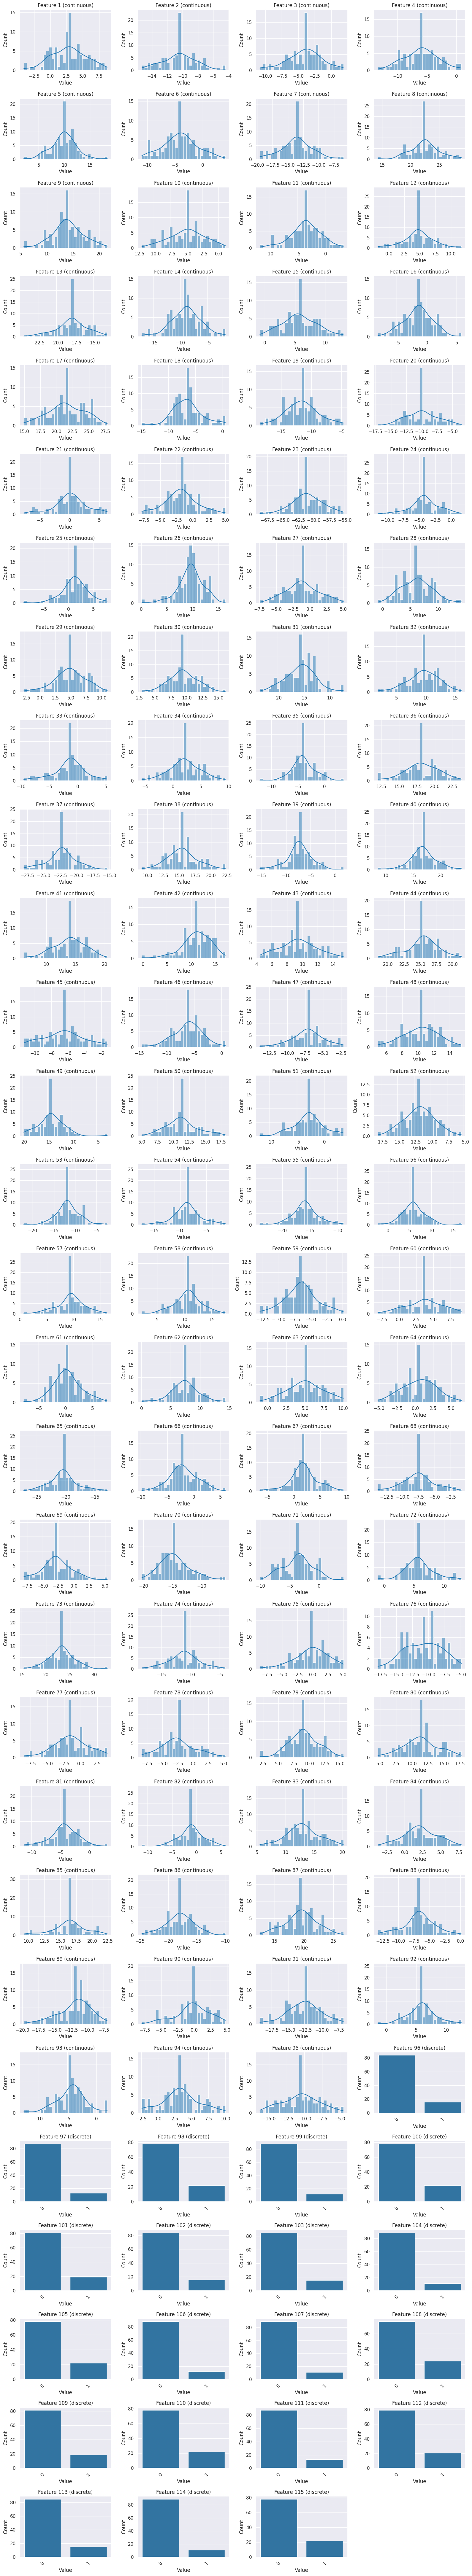

In [93]:
# Auto-select plot type per feature: countplot for discrete, hist+kde for continuous
def plot_feature_distributions_auto(
    X: np.ndarray,
    bins: int = 30,
    discrete_unique_max: int = 10,
    discrete_ratio_max: float = 0.05,
    integer_tol: float = 1e-8,
    max_cols: int = 4,
    figsize_per_subplot: tuple[float, float] = (4.0, 3.0),
) -> None:
    n_features = X.shape[1]
    n_cols = min(max_cols, n_features)
    n_rows = int(np.ceil(n_features / n_cols))

    _, axes = plt.subplots(
        n_rows, n_cols, figsize=(figsize_per_subplot[0] * n_cols, figsize_per_subplot[1] * n_rows)
    )
    axes = np.array(axes).reshape(-1)

    for idx in range(n_features):
        values = X[:, idx]
        values = values[~np.isnan(values)]  # Guard against NaNs

        unique_vals = np.unique(values)
        n_unique = len(unique_vals)
        unique_ratio = n_unique / max(len(values), 1)

        is_integer_like = np.all(np.abs(values - np.round(values)) < integer_tol)
        is_discrete = is_integer_like and (
            n_unique <= discrete_unique_max or unique_ratio <= discrete_ratio_max
        )

        ax = axes[idx]
        if is_discrete:
            discrete_values = np.round(values).astype(int)
            sns.countplot(x=discrete_values, ax=ax, color="tab:blue")
            ax.set_title(f"Feature {idx + 1} (discrete)")
            ax.set_xlabel("Value")
            ax.set_ylabel("Count")
            ax.tick_params(axis="x", rotation=45)
        else:
            sns.histplot(values, bins=bins, kde=True, ax=ax, color="tab:blue")
            ax.set_title(f"Feature {idx + 1} (continuous)")
            ax.set_xlabel("Value")
            ax.set_ylabel("Count")

    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_feature_distributions_auto(X)

In [34]:
def centerData(data):
    
    mu = np.mean(data,axis=0)
    data = data - mu
    
    return data, mu

def normalize(data):

    mu = np.mean(data, axis=0)
    sd = np.std(data, axis=0)

    data = (data - mu)/sd
    return data, mu, sd

def perform_PCA(X: np.ndarray):
    # Perform PCA on the dataset X; first we center:

    X_centered, mu = centerData(X)
    
    pca = PCA(n_components=2)
    pca.fit(X_centered)
    X_pca = pca.transform(X_centered)
    return X_pca, pca.components_, pca.explained_variance_ratio_

In [35]:
X_pca, components, explained_variance_ratio = perform_PCA(X)

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values